# Strong Signal (log10_h = -13): Distance Likelihood Landscape

**Motivation:** The multi-CW analysis (notebook 02) showed that at `log10_h = -13`
the joint Δln L between correct and wrong pulsar distances becomes very large for
all scenarios. This notebook examines that regime in detail.

We test N_CW = {1, 2, 4, 7, 10} under all three scenarios:
- **Close in frequency:** CW sources within ±0.1 dex of $f_{\rm gw} = 10^{-8}$ Hz
- **Close in sky position:** CW sources within ~15° of each other on sky
- **Well-separated:** random CW source sky positions and frequencies

Both noisy (realistic white + red noise + GWB) and noise-free cases are presented
side-by-side so the effect of noise can be assessed directly.


In [1]:
import sys, importlib
sys.path.insert(0, ".")
import cw_helpers
importlib.reload(cw_helpers)
from cw_helpers import *
import matplotlib.pyplot as plt
from scipy.signal import find_peaks as scipy_find_peaks
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})


/home/mattm/miniforge3/envs/discotech/lib/python3.12/site-packages/enterprise/signals/utils.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import Requirement, resource_filename


## 1. Setup

In [2]:
Npulsars = 10
ent_psrs, disco_psrs = load_pulsars(Npulsars)
print(f"Loaded {Npulsars} pulsars")

log10_h = -13.0
seed = 1234
ncw_values = [1, 2, 4, 7, 10]
scenarios = ["close_freq", "close_sky", "well_separated"]
scenario_labels = {
    "close_freq": "Close in frequency",
    "close_sky": "Close in sky position",
    "well_separated": "Well-separated",
}

test_psr = disco_psrs[0]
test_psr_name = test_psr.name
print(f"Test pulsar: {test_psr_name}, pdist = {test_psr.pdist[0]:.4f} kpc")


FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cann

## 2. Noise-free case (log10_h = -13)

Inject pure CW signals with no noise to isolate the geometric/phase effect.
This is the cleanest test: the only thing that matters is whether the single
pulsar distance can simultaneously phase-connect all CW sources.


In [3]:
# Build CW parameter sets for noise-free injection
def make_cw_params(n_sources, rng, scenario="well_separated"):
    # Generate n_sources CW parameter dicts.
    sources = []
    for i in range(n_sources):
        if scenario == "close_freq":
            l10f = -8.0 + rng.uniform(-0.1, 0.1)
            cgt = rng.uniform(-1, 1)
            gp = rng.uniform(0, 2 * np.pi)
        elif scenario == "close_sky":
            l10f = rng.uniform(-8.5, -7.5)
            cgt = np.clip(0.3 + rng.uniform(-0.05, 0.05), -1, 1)
            gp = 2.5 + rng.uniform(-0.055, 0.055)
        else:
            l10f = rng.uniform(-8.5, -7.5)
            cgt = rng.uniform(-1, 1)
            gp = rng.uniform(0, 2 * np.pi)

        sources.append({
            "cos_gwtheta": cgt, "gwphi": gp,
            "cos_inc": rng.uniform(-1, 1),
            "log10_mc": 9.0,
            "log10_fgw": l10f,
            "log10_h": log10_h,
            "phase0": rng.uniform(0, 2 * np.pi),
            "psi": rng.uniform(0, np.pi),
        })
    return sources

# Run noise-free scans
noisefree_results = {}

for scenario in scenarios:
    print(f"\n{'='*60}")
    print(f"Noise-free | {scenario_labels[scenario]}")
    print(f"{'='*60}")

    for ncw in ncw_values:
        rng_local = np.random.default_rng(42)
        cw_params = make_cw_params(ncw, rng_local, scenario=scenario)

        rmap, _ = inject_noisefree_cw(disco_psrs, cw_params)
        logl_fn, pkeys, bvals = build_noisefree_likelihood(disco_psrs, rmap, ncw, cw_params)

        ll_truth = float(logl_fn(bvals))

        # Per-pulsar scan on test pulsar
        dkey = f"{test_psr_name}_cw_p_dist"
        true_d = test_psr.pdist[0]
        all_dL = [compute_mode_spacing(cp["cos_gwtheta"], cp["gwphi"],
                                       cp["log10_fgw"], test_psr.pos) for cp in cw_params]
        min_dL = min(all_dL)
        max_dL = max(all_dL)
        scan_half = 10 * max_dL
        scan_d, scan_ll = scan_pulsar_distance(
            logl_fn, bvals, pkeys, dkey,
            max(0.01, true_d - scan_half), true_d + scan_half, n_points=5000,
        )
        analysis = analyze_peaks(scan_d, scan_ll, true_d, mode_spacing=min_dL)

        # Joint: best wrong mode within EM prior for each pulsar
        joint = compute_joint_best_wrong_in_prior(
            logl_fn, bvals, pkeys,
            ent_psrs, disco_psrs, cw_params, n_sigma=3.0,
        )

        key = (scenario, ncw)
        noisefree_results[key] = {
            "scan_d": scan_d, "scan_ll": scan_ll,
            "true_dist": true_d, "min_dL": min_dL, "max_dL": max_dL,
            "ll_truth": ll_truth,
            "analysis": analysis,
            "delta_joint": joint["delta_lnL"],
            "per_psr_delta": analysis["delta_lnL_truth_vs_best_wrong"],
        }

        delta_pp = analysis["delta_lnL_truth_vs_best_wrong"]
        delta_j = joint["delta_lnL"]
        print(f"  N_CW={ncw:2d}: per-psr Delta={delta_pp:.2f}, joint Delta={delta_j:.2f}")
        jax.clear_caches()

print("\nNoise-free scans complete!")



Noise-free | Close in frequency
  N_CW= 1: per-psr Delta=nan, joint Delta=0.10
  N_CW= 2: per-psr Delta=3.14, joint Delta=56.17
  N_CW= 4: per-psr Delta=16.53, joint Delta=124.79
  N_CW= 7: per-psr Delta=-0.81, joint Delta=726.40
  N_CW=10: per-psr Delta=-2.78, joint Delta=1389.77

Noise-free | Close in sky position
  N_CW= 1: per-psr Delta=-0.00, joint Delta=1.14
  N_CW= 2: per-psr Delta=-0.00, joint Delta=3.87
  N_CW= 4: per-psr Delta=0.02, joint Delta=54.29
  N_CW= 7: per-psr Delta=0.77, joint Delta=198.92
  N_CW=10: per-psr Delta=2.58, joint Delta=377.17

Noise-free | Well-separated
  N_CW= 1: per-psr Delta=nan, joint Delta=0.07
  N_CW= 2: per-psr Delta=0.89, joint Delta=12.77
  N_CW= 4: per-psr Delta=28.72, joint Delta=68.54
  N_CW= 7: per-psr Delta=-6.00, joint Delta=382.05
  N_CW=10: per-psr Delta=3.13, joint Delta=776.90

Noise-free scans complete!


## 3. Noisy case (log10_h = -13)

Enterprise simulation with realistic white noise, red noise, and GWB,
followed by discovery likelihood evaluation.


In [4]:
noisy_results = {}

for scenario in scenarios:
    print(f"\n{'='*60}")
    print(f"Noisy | {scenario_labels[scenario]}")
    print(f"{'='*60}")

    for ncw in ncw_values:
        rng = np.random.default_rng(seed)
        np.random.seed(seed)

        pta, cw_names, Tspan = build_enterprise_pta(ent_psrs, ncw)
        inj_params = generate_injection_params(
            pta, ent_psrs, ncw, cw_names, log10_h, scenario=scenario, rng=rng,
        )

        sim_resids = simulate(pta, inj_params)
        resid_map = {getattr(p, "name", p): y for p, y in zip(pta.pulsars, sim_resids)}

        logl_fn, pkeys, bvals = build_disco_likelihood(
            disco_psrs, resid_map, ncw, inj_params, cw_names,
        )

        ll_truth = float(logl_fn(bvals))

        # Per-pulsar scan on test pulsar
        dkey = f"{test_psr_name}_cw_p_dist"
        true_d = ent_psrs[0].pdist[0]

        # Mode spacings
        all_dL = []
        for name in cw_names:
            _dL = compute_mode_spacing(
                inj_params[f"{name}_cos_gwtheta"],
                inj_params[f"{name}_gwphi"],
                inj_params[f"{name}_log10_fgw"],
                test_psr.pos,
            )
            all_dL.append(_dL)
        min_dL = min(all_dL)
        max_dL = max(all_dL)
        scan_half = 10 * max_dL

        scan_d, scan_ll = scan_pulsar_distance(
            logl_fn, bvals, pkeys, dkey,
            max(0.01, true_d - scan_half), true_d + scan_half, n_points=5000,
        )
        analysis = analyze_peaks(scan_d, scan_ll, true_d, mode_spacing=min_dL)

        # Joint: best wrong mode within EM prior
        joint = compute_joint_best_wrong_in_prior(
            logl_fn, bvals, pkeys,
            ent_psrs, disco_psrs, inj_params,
            cw_block_names=cw_names, n_sigma=3.0,
        )

        key = (scenario, ncw)
        noisy_results[key] = {
            "scan_d": scan_d, "scan_ll": scan_ll,
            "true_dist": true_d, "min_dL": min_dL, "max_dL": max_dL,
            "ll_truth": ll_truth,
            "analysis": analysis,
            "delta_joint": joint["delta_lnL"],
            "per_psr_delta": analysis["delta_lnL_truth_vs_best_wrong"],
        }

        delta_pp = analysis["delta_lnL_truth_vs_best_wrong"]
        delta_j = joint["delta_lnL"]
        print(f"  N_CW={ncw:2d}: per-psr Delta={delta_pp:.2f}, joint Delta={delta_j:.2f}")
        jax.clear_caches()

print("\nNoisy scans complete!")



Noisy | Close in frequency


Duplicate signal B1855+09_cw from objects <Enterprise Signal object cw[cw2_cos_gwtheta, cw2_gwphi, cw2_cos_inc, cw2_log10_mc, cw2_log10_fgw, cw2_log10_h, cw2_phase0, cw2_psi, B1855+09_cw_p_dist]> and <Enterprise Signal object cw[cw_cos_gwtheta, cw_gwphi, cw_cos_inc, cw_log10_mc, cw_log10_fgw, cw_log10_h, cw_phase0, cw_psi, B1855+09_cw_p_dist]>.
This functionality was added in v1.1.0 and may cause post v1.1.0 functionality to break.
This may not cause other errors but it is recommended that you use a custom name for one of the duplicate signals.

Duplicate signal B1937+21_cw from objects <Enterprise Signal object cw[cw2_cos_gwtheta, cw2_gwphi, cw2_cos_inc, cw2_log10_mc, cw2_log10_fgw, cw2_log10_h, cw2_phase0, cw2_psi, B1937+21_cw_p_dist]> and <Enterprise Signal object cw[cw_cos_gwtheta, cw_gwphi, cw_cos_inc, cw_log10_mc, cw_log10_fgw, cw_log10_h, cw_phase0, cw_psi, B1937+21_cw_p_dist]>.
This functionality was added in v1.1.0 and may cause post v1.1.0 functionality to break.
This may not

  N_CW= 1: per-psr Delta=-0.01, joint Delta=38.64


Duplicate signal B1855+09_cw from objects <Enterprise Signal object cw[cw2_cos_gwtheta, cw2_gwphi, cw2_cos_inc, cw2_log10_mc, cw2_log10_fgw, cw2_log10_h, cw2_phase0, cw2_psi, B1855+09_cw_p_dist]> and <Enterprise Signal object cw[cw_cos_gwtheta, cw_gwphi, cw_cos_inc, cw_log10_mc, cw_log10_fgw, cw_log10_h, cw_phase0, cw_psi, B1855+09_cw_p_dist]>.
This functionality was added in v1.1.0 and may cause post v1.1.0 functionality to break.
This may not cause other errors but it is recommended that you use a custom name for one of the duplicate signals.

Duplicate signal B1855+09_cw from objects <Enterprise Signal object cw[cw3_cos_gwtheta, cw3_gwphi, cw3_cos_inc, cw3_log10_mc, cw3_log10_fgw, cw3_log10_h, cw3_phase0, cw3_psi, B1855+09_cw_p_dist]> and <Enterprise Signal object cw[cw_cos_gwtheta, cw_gwphi, cw_cos_inc, cw_log10_mc, cw_log10_fgw, cw_log10_h, cw_phase0, cw_psi, B1855+09_cw_p_dist]>.
This functionality was added in v1.1.0 and may cause post v1.1.0 functionality to break.
This may not

  N_CW= 2: per-psr Delta=21.02, joint Delta=214.53


...

  N_CW= 2: per-psr Delta=-0.29, joint Delta=174.15


Duplicate signal B1855+09_cw from objects <Enterprise Signal object cw[cw2_cos_gwtheta, cw2_gwphi, cw2_cos_inc, cw2_log10_mc, cw2_log10_fgw, cw2_log10_h, cw2_phase0, cw2_psi, B1855+09_cw_p_dist]> and <Enterprise Signal object cw[cw_cos_gwtheta, cw_gwphi, cw_cos_inc, cw_log10_mc, cw_log10_fgw, cw_log10_h, cw_phase0, cw_psi, B1855+09_cw_p_dist]>.
This functionality was added in v1.1.0 and may cause post v1.1.0 functionality to break.
This may not cause other errors but it is recommended that you use a custom name for one of the duplicate signals.

Duplicate signal B1855+09_cw from objects <Enterprise Signal object cw[cw3_cos_gwtheta, cw3_gwphi, cw3_cos_inc, cw3_log10_mc, cw3_log10_fgw, cw3_log10_h, cw3_phase0, cw3_psi, B1855+09_cw_p_dist]> and <Enterprise Signal object cw[cw_cos_gwtheta, cw_gwphi, cw_cos_inc, cw_log10_mc, cw_log10_fgw, cw_log10_h, cw_phase0, cw_psi, B1855+09_cw_p_dist]>.
This functionality was added in v1.1.0 and may cause post v1.1.0 functionality to break.
This may not

  N_CW= 4: per-psr Delta=32.56, joint Delta=1313.66
  N_CW= 7: per-psr Delta=39.04, joint Delta=1359.54


Duplicate signal B1855+09_cw from objects <Enterprise Signal object cw[cw2_cos_gwtheta, cw2_gwphi, cw2_cos_inc, cw2_log10_mc, cw2_log10_fgw, cw2_log10_h, cw2_phase0, cw2_psi, B1855+09_cw_p_dist]> and <Enterprise Signal object cw[cw_cos_gwtheta, cw_gwphi, cw_cos_inc, cw_log10_mc, cw_log10_fgw, cw_log10_h, cw_phase0, cw_psi, B1855+09_cw_p_dist]>.
This functionality was added in v1.1.0 and may cause post v1.1.0 functionality to break.
This may not cause other errors but it is recommended that you use a custom name for one of the duplicate signals.

Duplicate signal B1855+09_cw from objects <Enterprise Signal object cw[cw3_cos_gwtheta, cw3_gwphi, cw3_cos_inc, cw3_log10_mc, cw3_log10_fgw, cw3_log10_h, cw3_phase0, cw3_psi, B1855+09_cw_p_dist]> and <Enterprise Signal object cw[cw_cos_gwtheta, cw_gwphi, cw_cos_inc, cw_log10_mc, cw_log10_fgw, cw_log10_h, cw_phase0, cw_psi, B1855+09_cw_p_dist]>.
This functionality was added in v1.1.0 and may cause post v1.1.0 functionality to break.
This may not

  N_CW=10: per-psr Delta=62.54, joint Delta=2261.85

Noisy scans complete!


## 4. Distance landscape comparison: noise-free vs noisy

For each scenario, show the test pulsar's distance landscape side-by-side
(noise-free left, noisy right) at selected N_CW values.


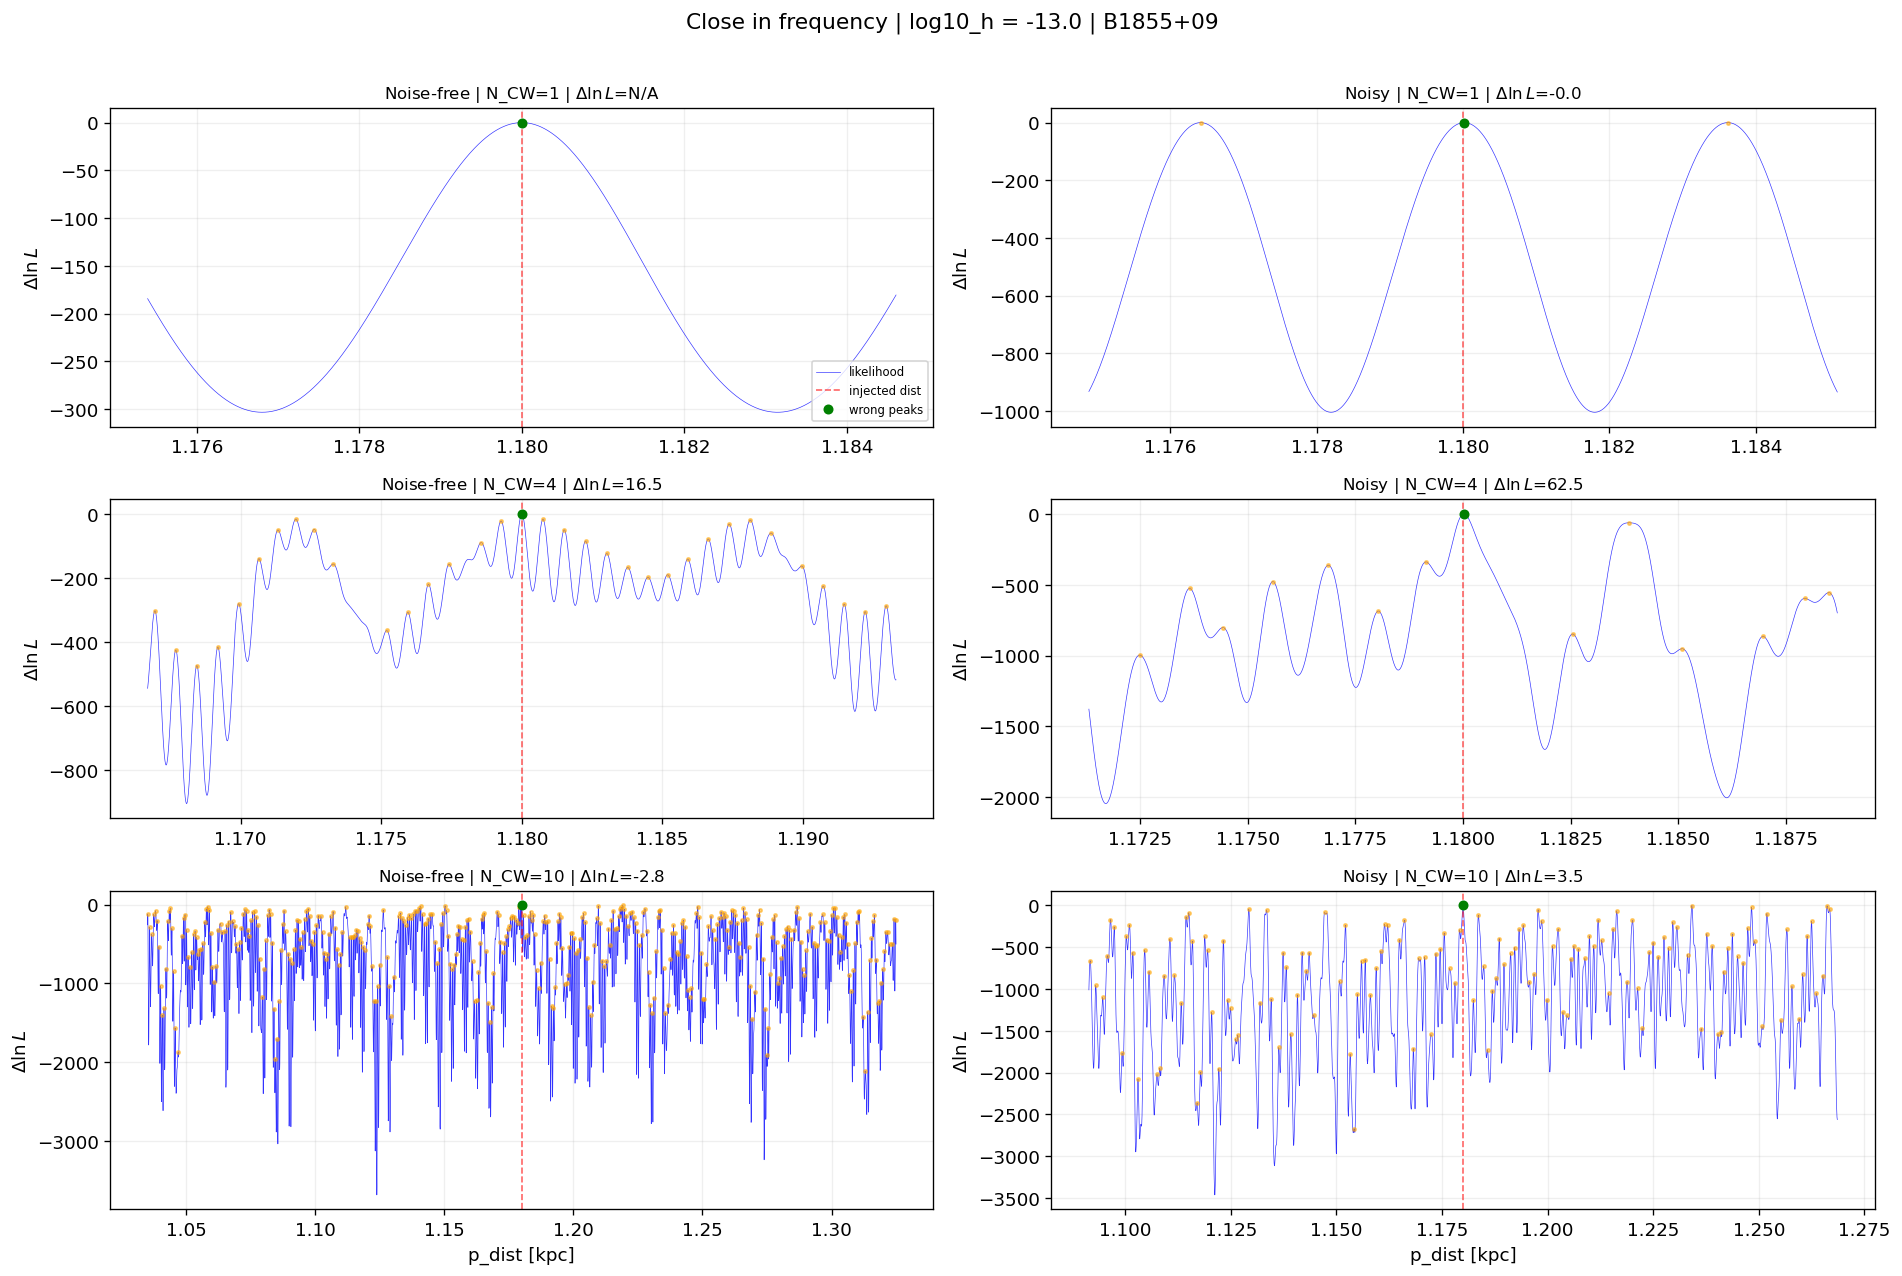

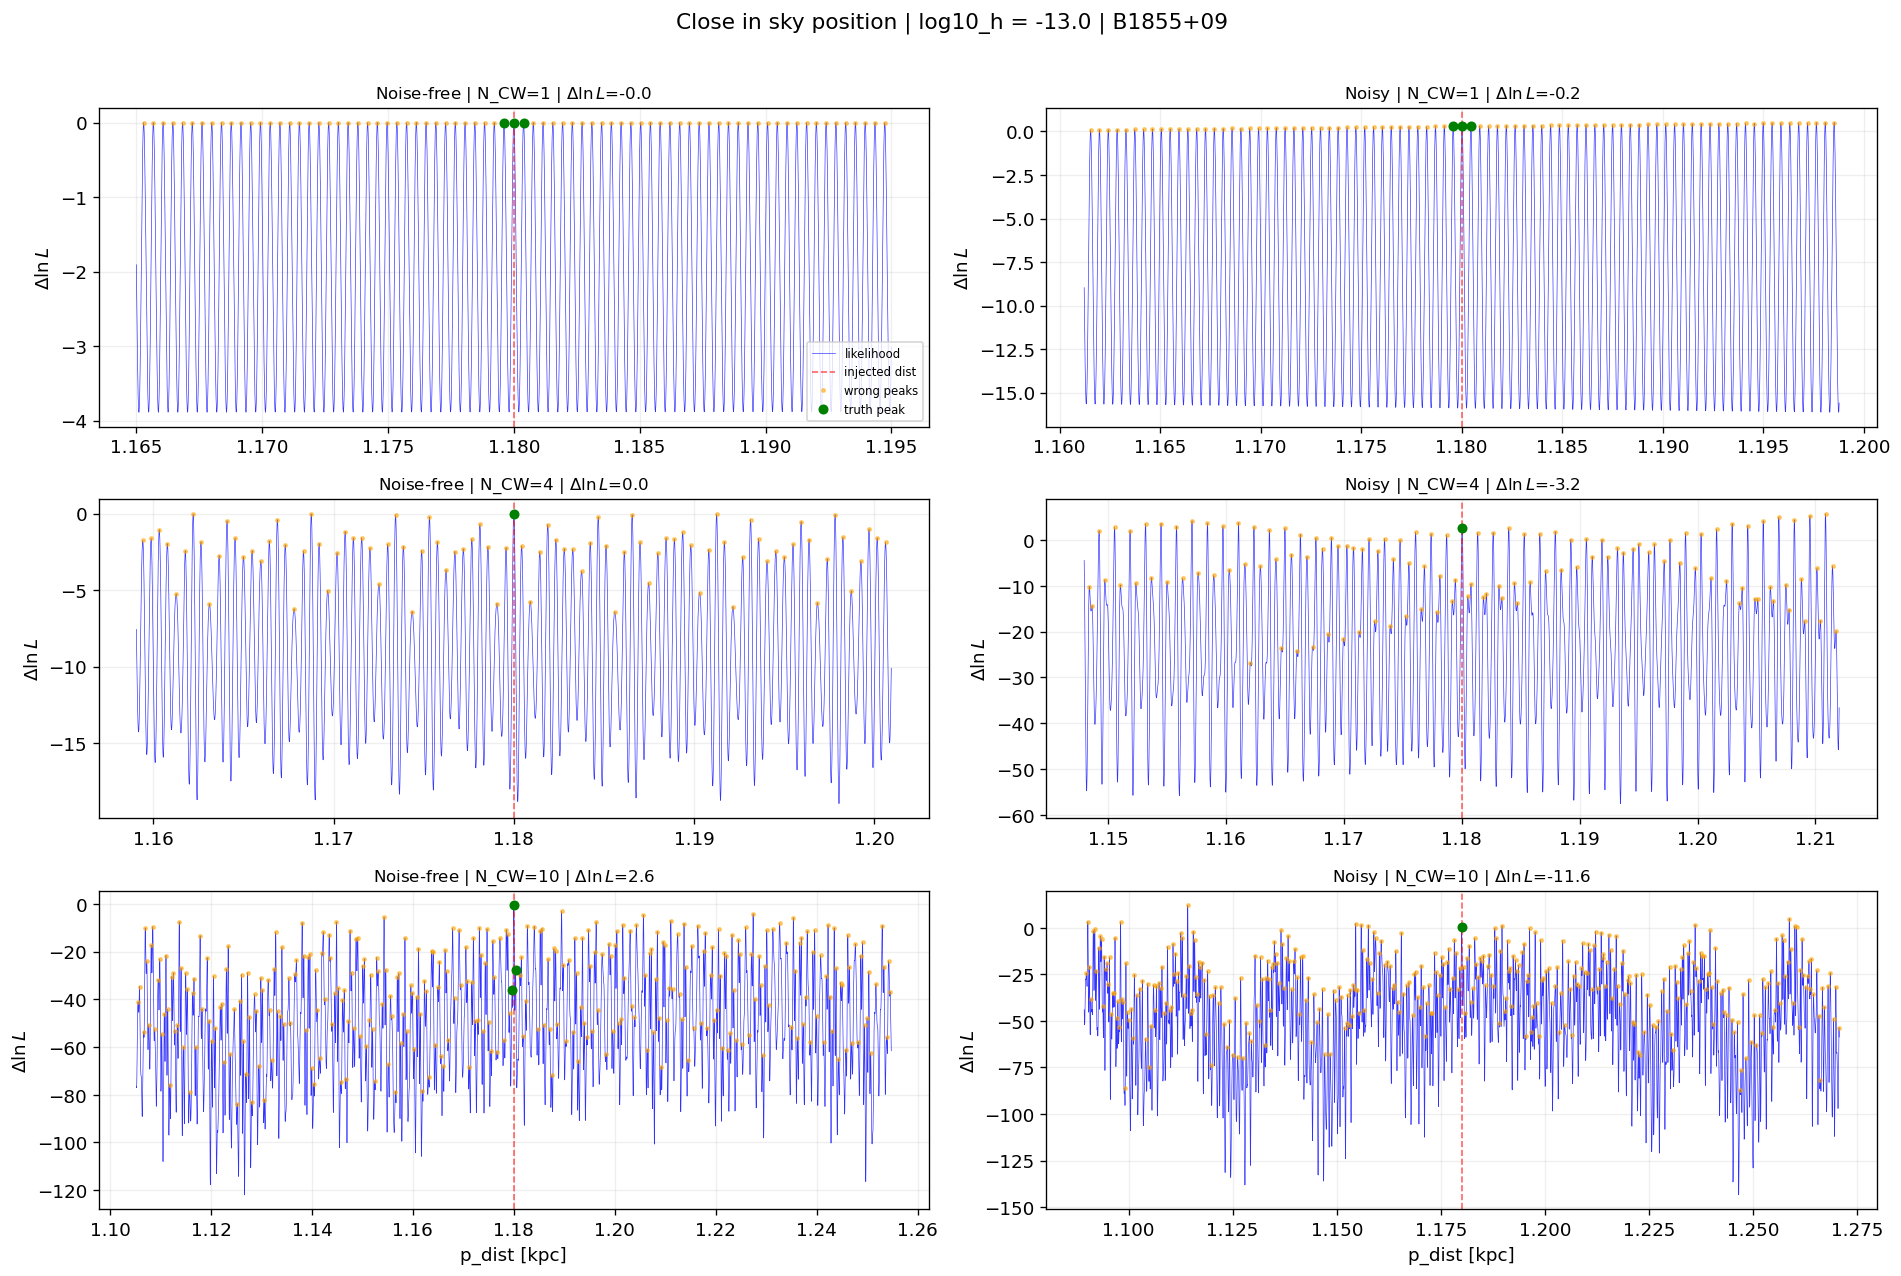

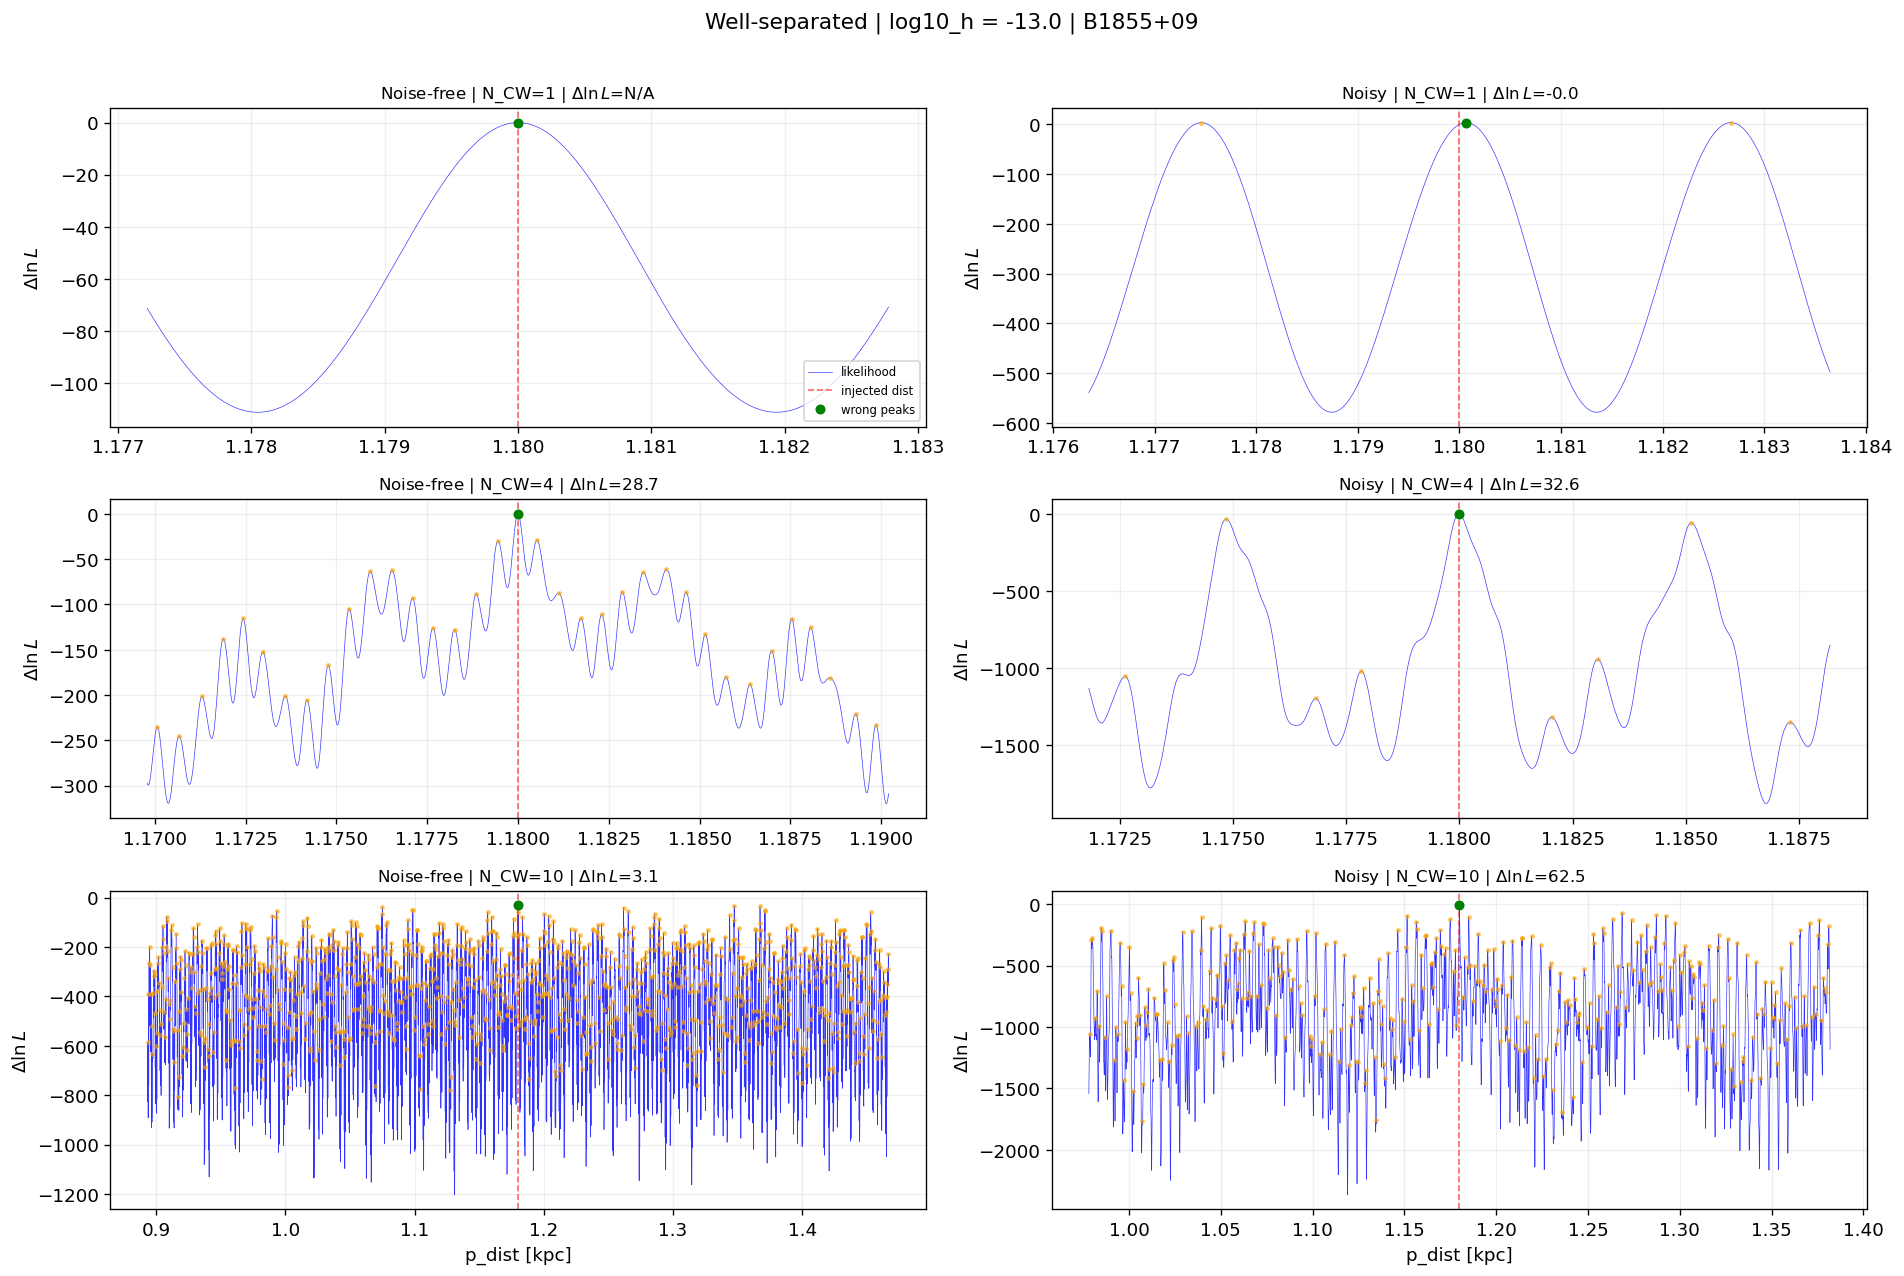

In [5]:
plot_ncws = [1, 4, 10]

for scenario in scenarios:
    fig, axes = plt.subplots(len(plot_ncws), 2, figsize=(16, 3.5 * len(plot_ncws)))

    for row, ncw in enumerate(plot_ncws):
        for col, (results, label) in enumerate([
            (noisefree_results, "Noise-free"),
            (noisy_results, "Noisy"),
        ]):
            ax = axes[row, col]
            key = (scenario, ncw)
            r = results[key]
            scan_d, scan_ll = r["scan_d"], r["scan_ll"]
            baseline = r["ll_truth"]
            rel_ll = scan_ll - baseline

            ax.plot(scan_d, rel_ll, "b-", lw=0.4, alpha=0.8)
            ax.axvline(r["true_dist"], color="red", ls="--", lw=1, alpha=0.6)

            a = r["analysis"]
            if len(a["peak_distances"]) > 0:
                truth_mask = np.abs(a["peak_distances"] - r["true_dist"]) < 0.3 * r["min_dL"]
                wrong_mask = ~truth_mask
                if np.any(wrong_mask):
                    ax.plot(a["peak_distances"][wrong_mask],
                            a["peak_heights"][wrong_mask] - baseline,
                            "o", color="orange", ms=2, alpha=0.5)
                if np.any(truth_mask):
                    ax.plot(a["peak_distances"][truth_mask],
                            a["peak_heights"][truth_mask] - baseline,
                            "o", color="green", ms=5)

            delta = a["delta_lnL_truth_vs_best_wrong"]
            delta_str = f"{delta:.1f}" if not np.isnan(delta) else "N/A"
            ax.set_ylabel(r"$\Delta \ln L$")
            ax.set_title(f"{label} | N_CW={ncw} | "
                         r"$\Delta\ln L$=" + delta_str, fontsize=10)
            ax.grid(True, alpha=0.2)

            if row == 0 and col == 0:
                ax.legend(["likelihood", "injected dist", "wrong peaks", "truth peak"],
                          fontsize=7, loc="lower right")

    axes[-1, 0].set_xlabel("p_dist [kpc]")
    axes[-1, 1].set_xlabel("p_dist [kpc]")
    fig.suptitle(f"{scenario_labels[scenario]} | log10_h = {log10_h} | {test_psr_name}",
                 fontsize=13, y=1.01)
    fig.tight_layout()
    plt.show()


## 5. Summary: Δln L vs N_CW (noise-free vs noisy)

The key comparison: how does the distance penalty scale with N_CW,
and how much does noise change the picture?


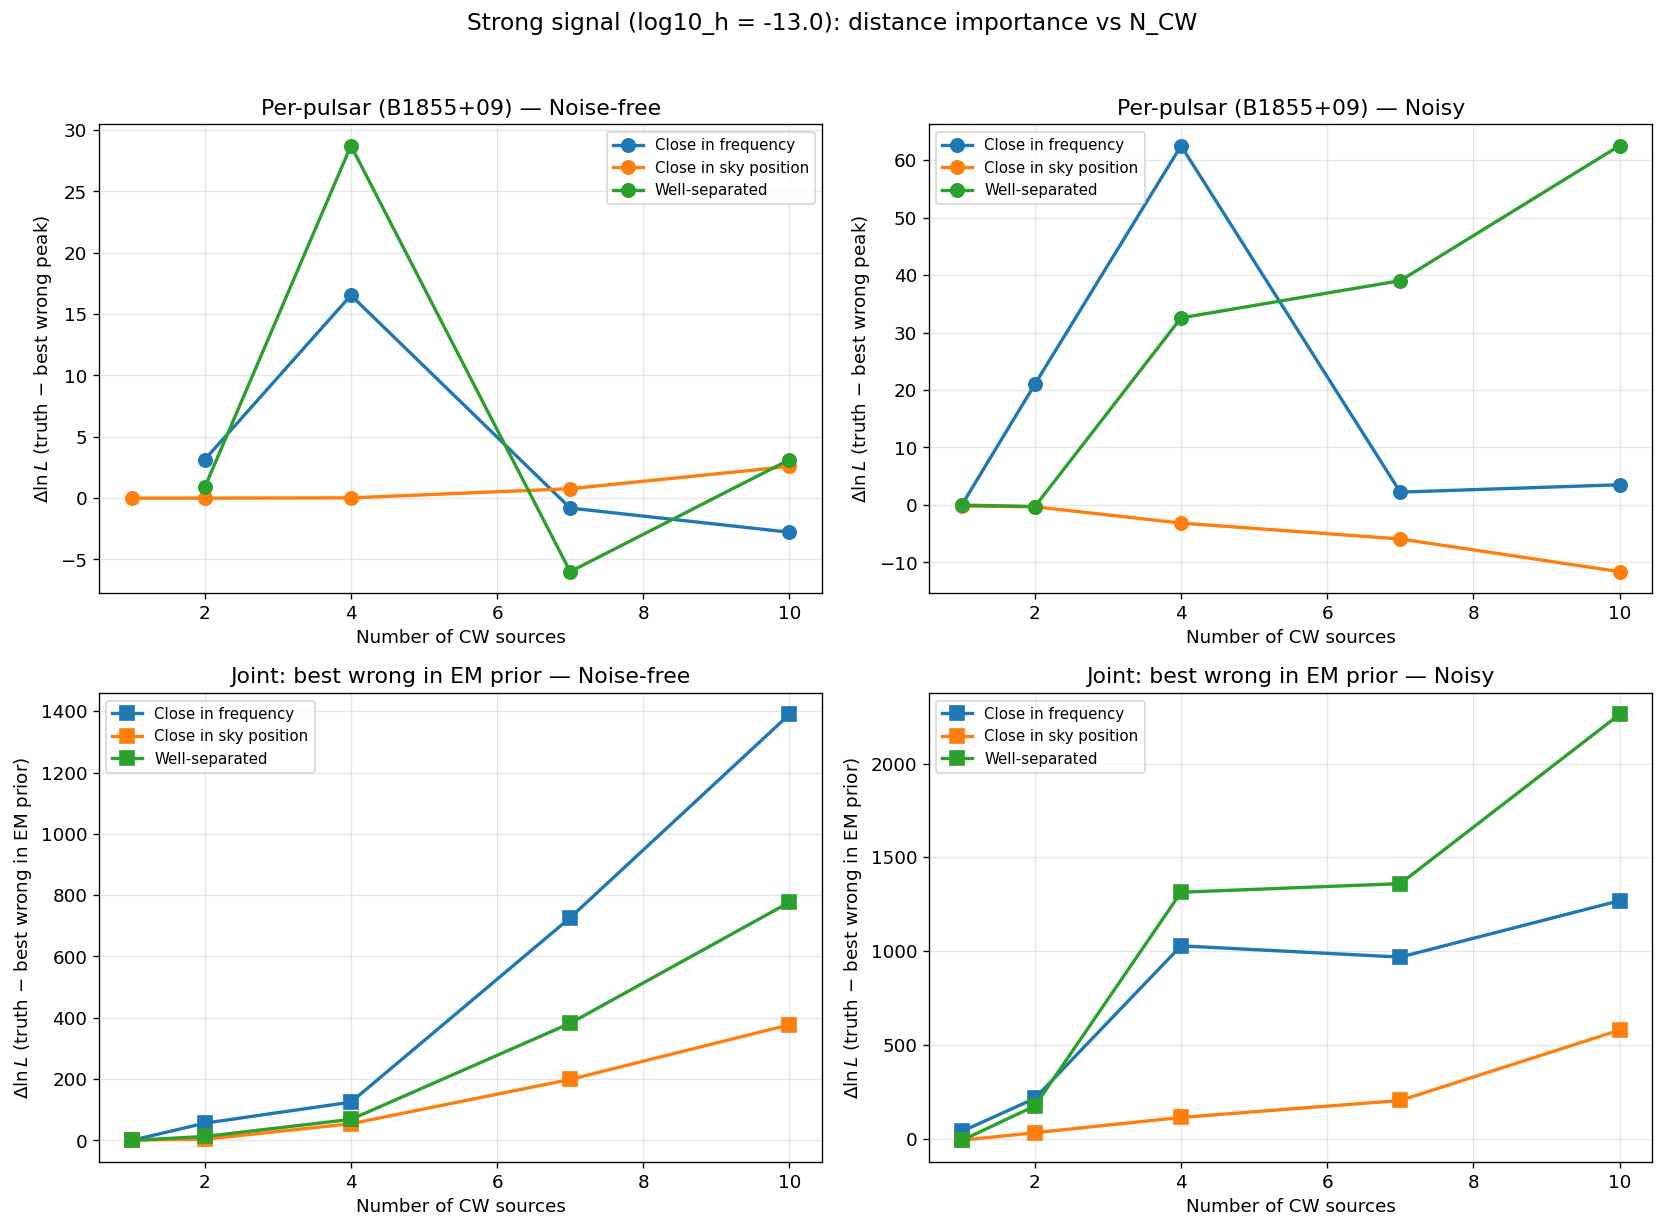

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Row 1: Per-pulsar Δln L
for col, (results, label) in enumerate([
    (noisefree_results, "Noise-free"),
    (noisy_results, "Noisy"),
]):
    ax = axes[0, col]
    for scenario in scenarios:
        deltas = [results[(scenario, n)]["per_psr_delta"] for n in ncw_values]
        ax.plot(ncw_values, deltas, "o-", label=scenario_labels[scenario], lw=2, ms=8)
    ax.set_xlabel("Number of CW sources")
    ax.set_ylabel(r"$\Delta \ln L$ (truth $-$ best wrong peak)")
    ax.set_title(f"Per-pulsar ({test_psr_name}) — {label}")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Row 2: Joint Δln L
for col, (results, label) in enumerate([
    (noisefree_results, "Noise-free"),
    (noisy_results, "Noisy"),
]):
    ax = axes[1, col]
    for scenario in scenarios:
        deltas = [results[(scenario, n)]["delta_joint"] for n in ncw_values]
        ax.plot(ncw_values, deltas, "s-", label=scenario_labels[scenario], lw=2, ms=8)
    ax.set_xlabel("Number of CW sources")
    ax.set_ylabel(r"$\Delta \ln L$ (truth $-$ best wrong in EM prior)")
    ax.set_title(f"Joint: best wrong in EM prior — {label}")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle(f"Strong signal (log10_h = {log10_h}): distance importance vs N_CW",
             fontsize=14, y=1.02)
fig.tight_layout()
plt.show()


## 6. Peak height distributions (noise-free vs noisy)

For each N_CW, collect all wrong-mode peak heights relative to the truth peak.
Noise-free should show a clean trend; noisy may show scatter.


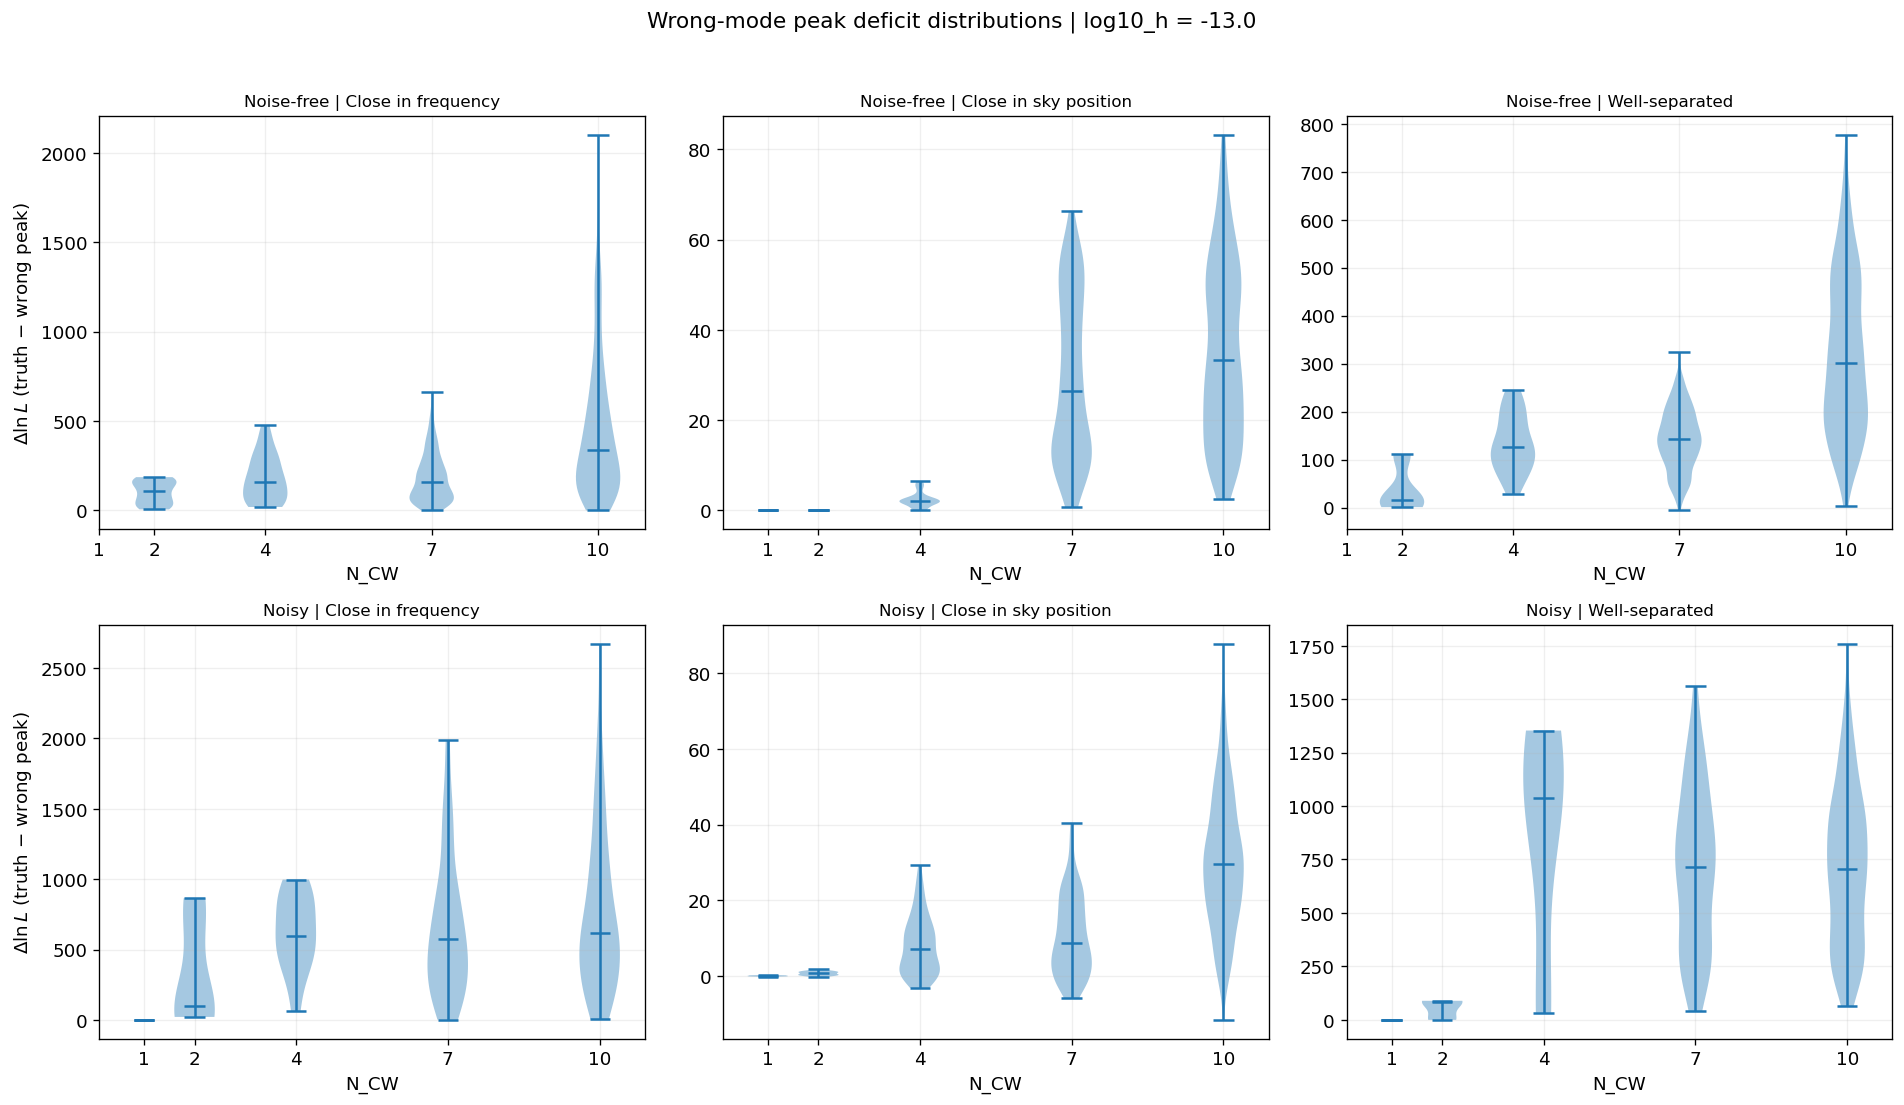

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for row, (results, row_label) in enumerate([
    (noisefree_results, "Noise-free"),
    (noisy_results, "Noisy"),
]):
    for col, scenario in enumerate(scenarios):
        ax = axes[row, col]
        positions = []
        data = []

        for ncw in ncw_values:
            key = (scenario, ncw)
            a = results[key]["analysis"]
            if a["n_peaks"] < 2:
                continue
            min_dL = results[key]["min_dL"]
            truth_mask = np.abs(a["peak_distances"] - results[key]["true_dist"]) < 0.3 * min_dL
            wrong_heights = a["peak_heights"][~truth_mask]
            if len(wrong_heights) > 0:
                deltas = a["truth_logl"] - wrong_heights
                positions.append(ncw)
                data.append(deltas)

        if data:
            parts = ax.violinplot(data, positions=positions, widths=0.8, showmedians=True)
            for pc in parts["bodies"]:
                pc.set_alpha(0.4)

        ax.set_xlabel("N_CW")
        ax.set_xticks(ncw_values)
        ax.set_title(f"{row_label} | {scenario_labels[scenario]}", fontsize=10)
        ax.grid(True, alpha=0.2)
        if col == 0:
            ax.set_ylabel(r"$\Delta \ln L$ (truth $-$ wrong peak)")

fig.suptitle(f"Wrong-mode peak deficit distributions | log10_h = {log10_h}",
             fontsize=13, y=1.02)
fig.tight_layout()
plt.show()


## 7. Summary tables

In [8]:
print("=" * 80)
print(f"STRONG SIGNAL SUMMARY: log10_h = {log10_h}")
print("=" * 80)

for results, label in [(noisefree_results, "NOISE-FREE"), (noisy_results, "NOISY")]:
    print(f"\n{label}")
    print(f"{'':25s}  Per-pulsar Delta ln L (truth peak - best wrong peak)")
    print(f"{'Scenario':25s} | " + " | ".join(f"N_CW={n:2d}" for n in ncw_values))
    print("-" * (25 + 3 + len(ncw_values) * 12))
    for scenario in scenarios:
        row = f"{scenario_labels[scenario]:25s} | "
        for ncw in ncw_values:
            d = results[(scenario, ncw)]["per_psr_delta"]
            row += f" {d:8.2f}  | "
        print(row)

    print(f"\n{'':25s}  Joint Delta ln L (truth vs best wrong mode within EM prior)")
    print(f"{'Scenario':25s} | " + " | ".join(f"N_CW={n:2d}" for n in ncw_values))
    print("-" * (25 + 3 + len(ncw_values) * 12))
    for scenario in scenarios:
        row = f"{scenario_labels[scenario]:25s} | "
        for ncw in ncw_values:
            d = results[(scenario, ncw)]["delta_joint"]
            row += f" {d:8.2f}  | "
        print(row)


STRONG SIGNAL SUMMARY: log10_h = -13.0

NOISE-FREE
                           Per-pulsar Delta ln L (truth peak - best wrong peak)
Scenario                  | N_CW= 1 | N_CW= 2 | N_CW= 4 | N_CW= 7 | N_CW=10
----------------------------------------------------------------------------------------
Close in frequency        |       nan  |      3.14  |     16.53  |     -0.81  |     -2.78  | 
Close in sky position     |     -0.00  |     -0.00  |      0.02  |      0.77  |      2.58  | 
Well-separated            |       nan  |      0.89  |     28.72  |     -6.00  |      3.13  | 

                           Joint Delta ln L (truth vs best wrong mode within EM prior)
Scenario                  | N_CW= 1 | N_CW= 2 | N_CW= 4 | N_CW= 7 | N_CW=10
----------------------------------------------------------------------------------------
Close in frequency        |      0.10  |     56.17  |    124.79  |    726.40  |   1389.77  | 
Close in sky position     |      1.14  |      3.87  |     54.29  |    198.9

## 8. Direct comparison: noisy vs noise-free Δln L

Scatter plot showing how noise affects the Δln L values.
Points above the diagonal mean noise *increased* the penalty;
points below mean noise reduced it (GP absorbing signal).


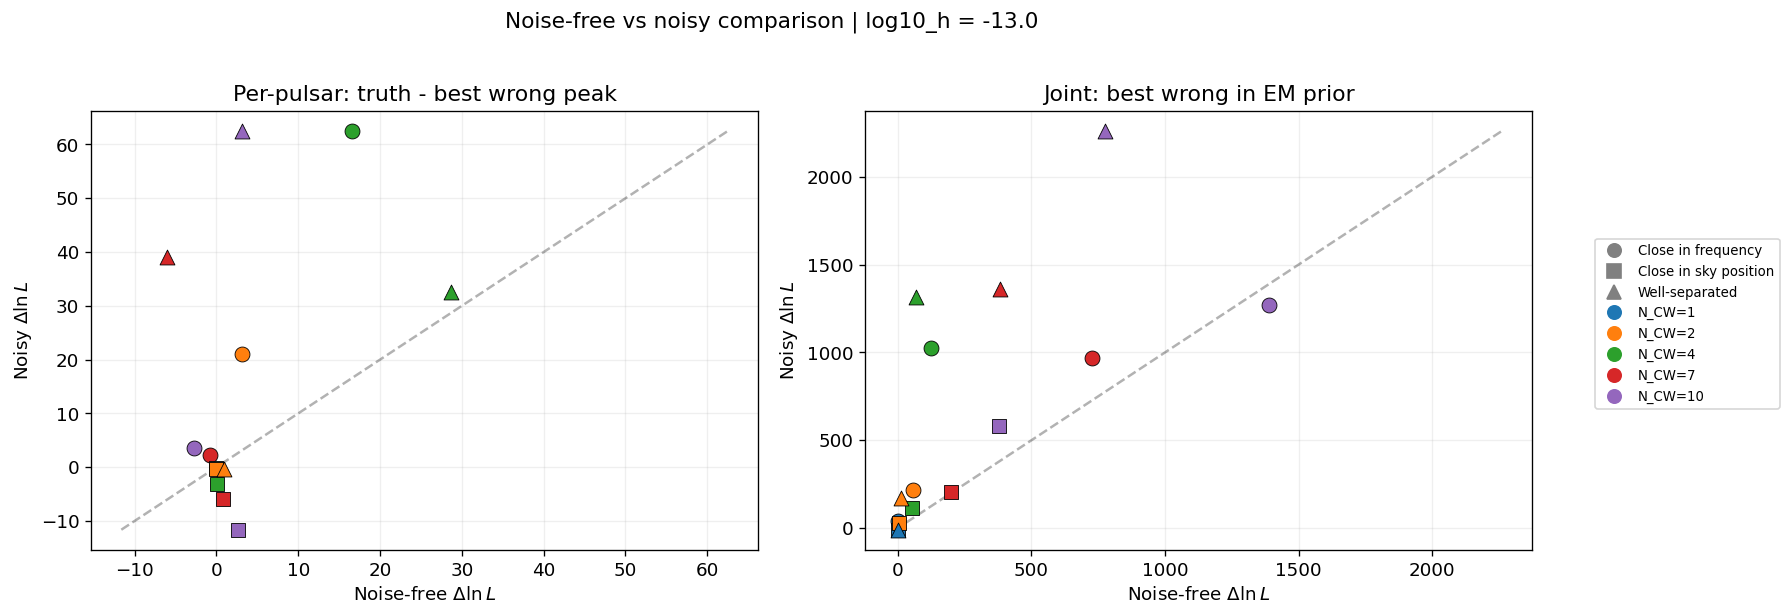

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
markers = {"close_freq": "o", "close_sky": "s", "well_separated": "^"}
colors_ncw = {1: "C0", 2: "C1", 4: "C2", 7: "C3", 10: "C4"}

# Per-pulsar
ax = axes[0]
for scenario in scenarios:
    for ncw in ncw_values:
        key = (scenario, ncw)
        nf = noisefree_results[key]["per_psr_delta"]
        ny = noisy_results[key]["per_psr_delta"]
        if np.isnan(nf) or np.isnan(ny):
            continue
        ax.scatter(nf, ny, marker=markers[scenario], color=colors_ncw[ncw],
                   s=80, edgecolors="k", linewidths=0.5, zorder=5)

# Diagonal
all_vals = []
for key in noisefree_results:
    nf = noisefree_results[key]["per_psr_delta"]
    ny = noisy_results[key]["per_psr_delta"]
    if not np.isnan(nf) and not np.isnan(ny):
        all_vals.extend([nf, ny])
if all_vals:
    lo, hi = min(all_vals), max(all_vals)
    ax.plot([lo, hi], [lo, hi], "k--", alpha=0.3)

ax.set_xlabel(r"Noise-free $\Delta \ln L$")
ax.set_ylabel(r"Noisy $\Delta \ln L$")
ax.set_title("Per-pulsar: truth - best wrong peak")
ax.grid(True, alpha=0.2)

# Joint
ax = axes[1]
for scenario in scenarios:
    for ncw in ncw_values:
        key = (scenario, ncw)
        nf = noisefree_results[key]["delta_joint"]
        ny = noisy_results[key]["delta_joint"]
        ax.scatter(nf, ny, marker=markers[scenario], color=colors_ncw[ncw],
                   s=80, edgecolors="k", linewidths=0.5, zorder=5)

all_vals = []
for key in noisefree_results:
    all_vals.extend([noisefree_results[key]["delta_joint"], noisy_results[key]["delta_joint"]])
lo, hi = min(all_vals), max(all_vals)
ax.plot([lo, hi], [lo, hi], "k--", alpha=0.3)

ax.set_xlabel(r"Noise-free $\Delta \ln L$")
ax.set_ylabel(r"Noisy $\Delta \ln L$")
ax.set_title("Joint: best wrong in EM prior")
ax.grid(True, alpha=0.2)

# Legend
from matplotlib.lines import Line2D
handles = []
for scenario in scenarios:
    handles.append(Line2D([0], [0], marker=markers[scenario], color="gray",
                          label=scenario_labels[scenario], ms=8, ls="none"))
for ncw in ncw_values:
    handles.append(Line2D([0], [0], marker="o", color=colors_ncw[ncw],
                          label=f"N_CW={ncw}", ms=8, ls="none"))
fig.legend(handles=handles, loc="center right", fontsize=8, bbox_to_anchor=(1.15, 0.5))

fig.suptitle(f"Noise-free vs noisy comparison | log10_h = {log10_h}", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()


## Interpretation

At `log10_h = -13` the CW signal is strong enough that:

1. **Single CW:** Even for one source, the distance mode oscillations have significant
   amplitude. However, in the noise-free case, all modes should still be nearly equal.
   Any apparent preference for the truth mode comes from frequency evolution effects
   (the GR chirp makes the pulsar-term frequency slightly different at wrong distances).

2. **Multiple CWs:** The combinatorial constraint from multiple sources makes the truth
   distance strongly preferred. With 10 CWs, the Δln L should be very large.

3. **Noise effect:** The marginalized red noise GP can absorb part of the CW signal,
   which may either increase or decrease the apparent Δln L depending on the noise
   realization. The noise-free vs noisy scatter plot (Section 8) quantifies this.

4. **Scenario comparison:** If all three scenarios show similar scaling, the distance
   constraint is a generic multi-source effect, not specific to confused sources.
